<a href="https://colab.research.google.com/github/aathil28/Exit_Exam_Retest/blob/main/Exi_Exam_Retest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading libraries

In [47]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.2 MB/s eta 0:00:00


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import zipfile
import os
import joblib
import shutil

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from pyngrok import ngrok
from getpass import getpass

tf.keras.utils.set_random_seed(42)

#Loading data

In [3]:
df_attention = pd.read_csv('/content/artist_attention_summary.csv')
df_attention.head(10)

,artist_mbid,artist_name,artist_type,gender,country,begin_year,disambiguation,top_tags,source,release_count,first_release_year,last_release_year,total_pageviews,median_daily_views,pageview_days
0,e0bba708-bdd3-478d-84ea-c706413bedab,A. R. Rahman,Person,male,IN,1967.0,NaN,classical|soundtrack|indian|film score|world f...,MusicBrainz,100,1990.0,1997.0,63878,2052.0,30
1,cc2c9c3c-b7bc-4b8b-84d8-4fbd8779e493,Adele,Person,female,GB,1988.0,UK soul/jazz singer,pop|soul|blue-eyed soul|pop soul|neo soul,MusicBrainz,100,2005.0,2011.0,125704,4199.0,30
2,2f9ecbed-27be-40e6-abca-6de49d50299e,Aretha Franklin,Person,female,US,1942.0,NaN,soul|gospel|southern soul|deep soul|jazz,MusicBrainz,100,1956.0,1976.0,136849,4140.0,30
3,f4fdbb4c-e4b7-47a0-b83b-d91bbfcfa387,Ariana Grande,Person,female,US,1993.0,NaN,pop|r&b|dance-pop|contemporary r&b|dance,MusicBrainz,98,2011.0,2014.0,275088,9025.0,30
4,ed3f4831-e3e0-4dc0-9381-f5649e9df221,Arijit Singh,Person,male,IN,1987.0,NaN,bollywood|filmi|indian pop|gaana,MusicBrainz,100,2010.0,2023.0,0,NaN,0
5,89aa5ecb-59ad-46f5-b3eb-2d424e941f19,Bad Bunny,Person,male,PR,1994.0,NaN,reggaeton|trap latino|latin|latin trap|hip hop,MusicBrainz,94,2016.0,2018.0,113278,3759.0,30
6,859d0860-d480-4efd-970c-c05d5f1776b8,Beyoncé,Person,female,US,1981.0,NaN,pop|r&b|pop rap|contemporary r&b|soul,MusicBrainz,100,2002.0,2006.0,214686,6796.0,30
7,f4abc0b5-3f7a-4eff-8f78-ac078dbce533,Billie Eilish,Person,female,US,2001.0,NaN,electropop|alternative pop|pop|dark pop|altern...,MusicBrainz,100,2015.0,2019.0,191796,5537.0,30
8,48646387-1664-4c9a-9139-9bfd091b823c,BLACKPINK,Group,NaN,KR,2016.0,NaN,k-pop|girl group|3rd gen k-pop|pop|female vocals,MusicBrainz,100,2016.0,2019.0,328,11.0,30
9,72c536dc-7137-4477-a521-567eeb840fa8,Bob Dylan,Person,male,US,1941.0,NaN,folk rock|folk|rock|blues rock|singer-songwriter,MusicBrainz,100,1956.0,1973.0,214194,7063.0,30


#EDA

In [4]:
df_attention.shape

(42, 15)

In [5]:
df_attention.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   artist_mbid         42 non-null     object 
 1   artist_name         42 non-null     object 
 2   artist_type         42 non-null     object 
 3   gender              37 non-null     object 
 4   country             40 non-null     object 
 5   begin_year          41 non-null     float64
 6   disambiguation      19 non-null     object 
 7   top_tags            41 non-null     object 
 8   source              42 non-null     object 
 9   release_count       42 non-null     int64  
 10  first_release_year  40 non-null     float64
 11  last_release_year   40 non-null     float64
 12  total_pageviews     42 non-null     int64  
 13  median_daily_views  40 non-null     float64
 14  pageview_days       42 non-null     int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 5.1+ KB


In [6]:
df_attention.describe()

,begin_year,release_count,first_release_year,last_release_year,total_pageviews,median_daily_views,pageview_days
count,41.000000,42.000000,40.000000,40.000000,42.000000,40.00000,42.000000
mean,1976.804878,94.952381,1993.025000,2001.325000,213238.571429,6189.27500,28.404762
std,22.311678,21.519081,21.821523,19.970989,193265.319407,4617.48774,6.518490
min,1915.000000,0.000000,1939.000000,1946.000000,0.000000,1.00000,0.000000
25%,1963.000000,100.000000,1976.750000,1984.250000,110767.750000,3783.75000,30.000000
50%,1985.000000,100.000000,2003.000000,2010.500000,192503.000000,5784.00000,30.000000
75%,1991.000000,100.000000,2010.250000,2015.500000,264129.500000,8850.00000,30.000000
max,2016.000000,100.000000,2016.000000,2023.000000,790047.000000,24325.00000,30.000000


##Checking missing values

In [7]:
df_attention.isna().sum()

,0
artist_mbid,0
artist_name,0
artist_type,0
gender,5
country,2
begin_year,1
disambiguation,23
top_tags,1
source,0
release_count,0


##Checking duplicate records

In [8]:
df_attention.duplicated().sum()

np.int64(0)

In [9]:
print(df_attention.columns)

Index(['artist_mbid', 'artist_name', 'artist_type', 'gender', 'country',
       'begin_year', 'disambiguation', 'top_tags', 'source', 'release_count',
       'first_release_year', 'last_release_year', 'total_pageviews',
       'median_daily_views', 'pageview_days'],
      dtype='object')


##Find numerical and categorical column

In [12]:
# Find numerical columns
numerical_columns = df_attention.select_dtypes(include=['number']).columns.tolist()

# Find categorical columns
categorical_columns = df_attention.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['begin_year', 'release_count', 'first_release_year', 'last_release_year', 'total_pageviews', 'median_daily_views', 'pageview_days']

Categorical columns:
['artist_mbid', 'artist_name', 'artist_type', 'gender', 'country', 'disambiguation', 'top_tags', 'source']


##Analyse the distribution of artist type, gender and country

artist_type    0
gender         5
country        2
dtype: int64

Artist type distribution:
artist_type
Person    37
Group      5
Name: count, dtype: int64

Gender distribution:
gender
male      21
female    16
NaN        5
Name: count, dtype: int64

Country distribution:
country
US     24
GB      5
CA      3
IN      2
PR      2
KR      2
NaN     2
CO      2
Name: count, dtype: int64


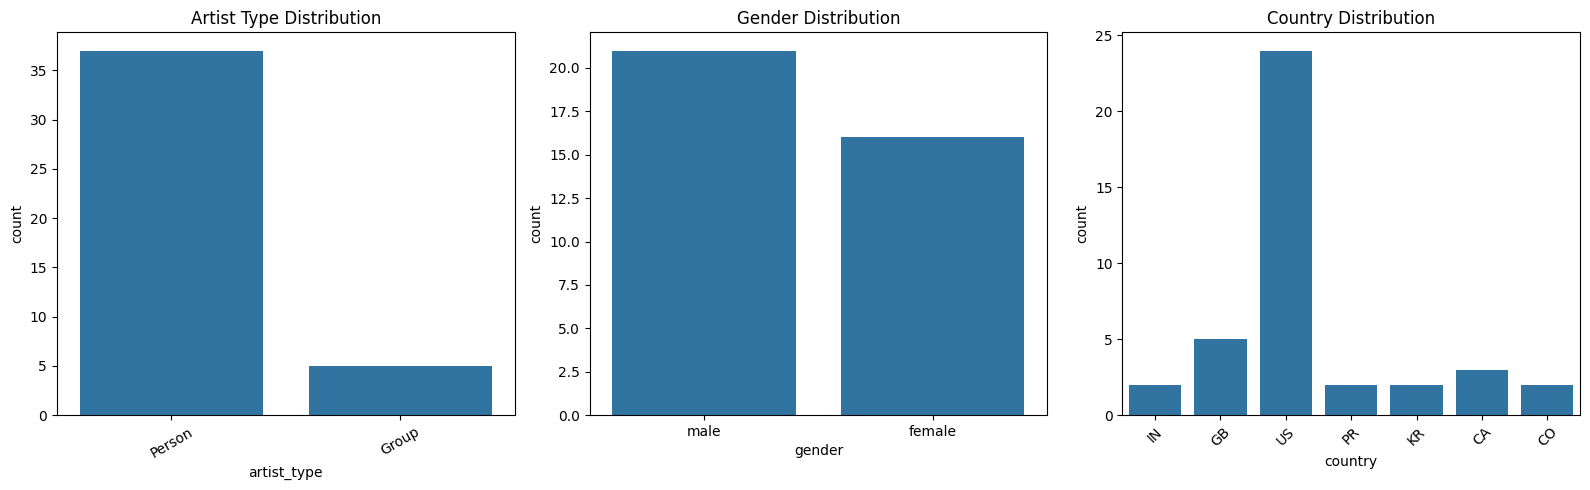

In [14]:
# Check missing values
print(df_attention[['artist_type', 'gender', 'country']].isnull().sum())

# Distribution of artist type
print("\nArtist type distribution:")
print(df_attention['artist_type'].value_counts(dropna=False))

# Distribution of gender
print("\nGender distribution:")
print(df_attention['gender'].value_counts(dropna=False))

# Distribution of countries
print("\nCountry distribution:")
print(df_attention['country'].value_counts(dropna=False))

# Visualize all three distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df_attention, x='artist_type', ax=axes[0])
axes[0].set_title('Artist Type Distribution')
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df_attention, x='gender', ax=axes[1])
axes[1].set_title('Gender Distribution')

sns.countplot(data=df_attention, x='country', ax=axes[2])
axes[2].set_title('Country Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##Explore the distribution of median_daily_views

count       40.00000
mean      6189.27500
std       4617.48774
min          1.00000
25%       3783.75000
50%       5784.00000
75%       8850.00000
max      24325.00000
Name: median_daily_views, dtype: float64


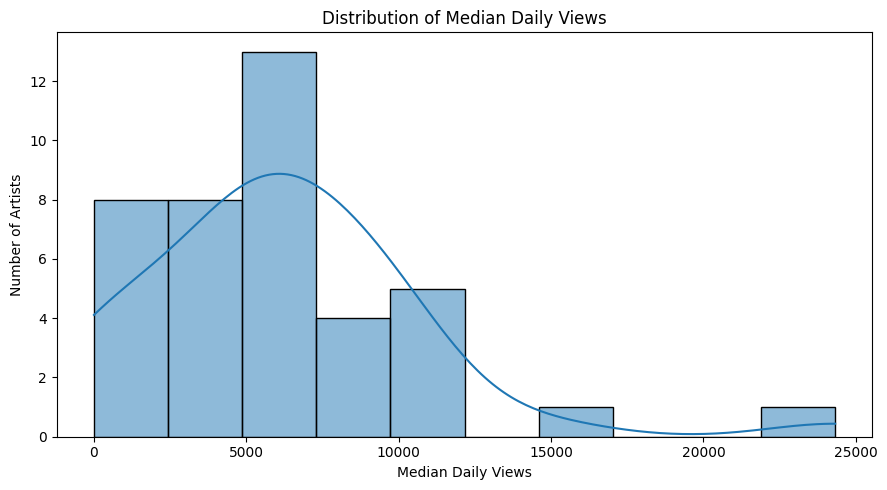

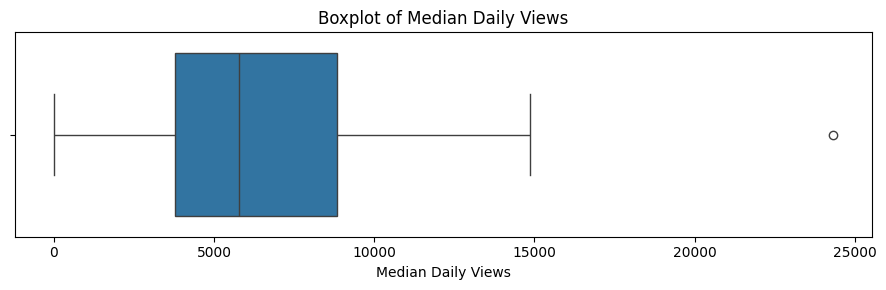

In [15]:
# Remove records where the target measure is missing
views = df_attention['median_daily_views'].dropna()

print(views.describe())

# Histogram with density curve
plt.figure(figsize=(9, 5))
sns.histplot(views, bins=10, kde=True)
plt.title('Distribution of Median Daily Views')
plt.xlabel('Median Daily Views')
plt.ylabel('Number of Artists')
plt.tight_layout()
plt.show()

# Boxplot to identify spread and potential outliers
plt.figure(figsize=(9, 3))
sns.boxplot(x=views)
plt.title('Boxplot of Median Daily Views')
plt.xlabel('Median Daily Views')
plt.tight_layout()
plt.show()

The distribution is right-skewed: most artists have comparatively lower or moderate daily views, while a small number of artists have much higher views.

Number of usable records: 40



Mean: approximately 6,189 views



Median: 5,784 views



Minimum: 1 view



Maximum: 24,325 views

The maximum is substantially higher than the median, and the mean is also higher than the median. These are indicators of a long right tail, although the histogram should be used to inspect the shape directly.

Conclusion: Audience attention varies considerably among artists. This variation supports converting the continuous view measure into categories for a multiclass classification task.

##Create the attention_level target variable

In [17]:
# We will use quantile-based categorization to divide the artists into Low, Medium and High attention groups.

# Remove missing target values
df = df_attention.dropna(subset=['median_daily_views']).copy()

# Create three attention categories
df['attention_level'] = pd.qcut(
    df['median_daily_views'],
    q=3,
    labels=[
        'Low attention',
        'Medium attention',
        'High attention'
    ]
)

# Display quantile boundaries
print("Quantile boundaries:")
print(df['median_daily_views'].quantile([0, 1/3, 2/3, 1]))

# Display artist and target
print(df[['artist_name', 'median_daily_views',
          'attention_level']].head(10))

Quantile boundaries:
0.000000        1.0
0.333333     4199.0
0.666667     7219.0
1.000000    24325.0
Name: median_daily_views, dtype: float64
        artist_name  median_daily_views   attention_level
0      A. R. Rahman              2052.0     Low attention
1             Adele              4199.0     Low attention
2   Aretha Franklin              4140.0     Low attention
3     Ariana Grande              9025.0    High attention
5         Bad Bunny              3759.0     Low attention
6           Beyoncé              6796.0  Medium attention
7     Billie Eilish              5537.0  Medium attention
8         BLACKPINK                11.0     Low attention
9         Bob Dylan              7063.0  Medium attention
10       Bruno Mars              9836.0    High attention


##Analyse the distribution of the three attention categories

attention_level
Low attention       14
Medium attention    12
High attention      14
Name: count, dtype: int64


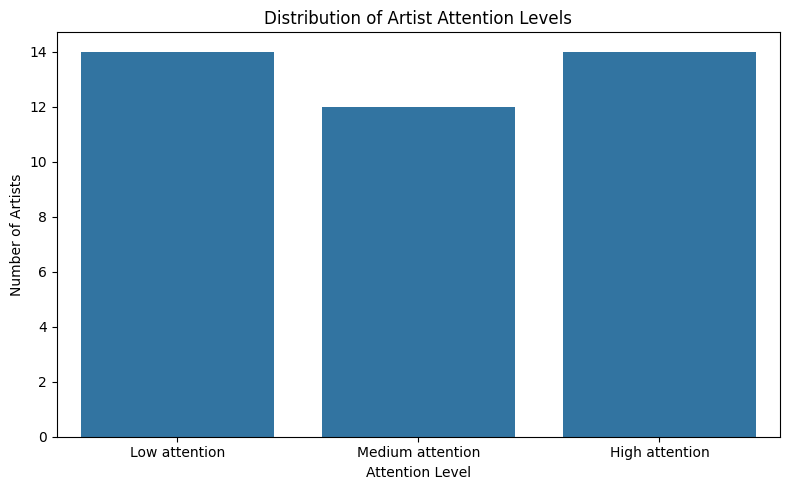

In [18]:
# Count artists in each category
attention_counts = df['attention_level'].value_counts(
    sort=False
)

print(attention_counts)

# Bar chart
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='attention_level',
    order=[
        'Low attention',
        'Medium attention',
        'High attention'
    ]
)
plt.title('Distribution of Artist Attention Levels')
plt.xlabel('Attention Level')
plt.ylabel('Number of Artists')
plt.tight_layout()
plt.show()

The distribution is relatively balanced: Low and High attention each contain 14 artists, while Medium attention contains 12. This is useful for classification because no single class overwhelmingly dominates the dataset.

##Visualise the relationship between artist characteristics and attention level

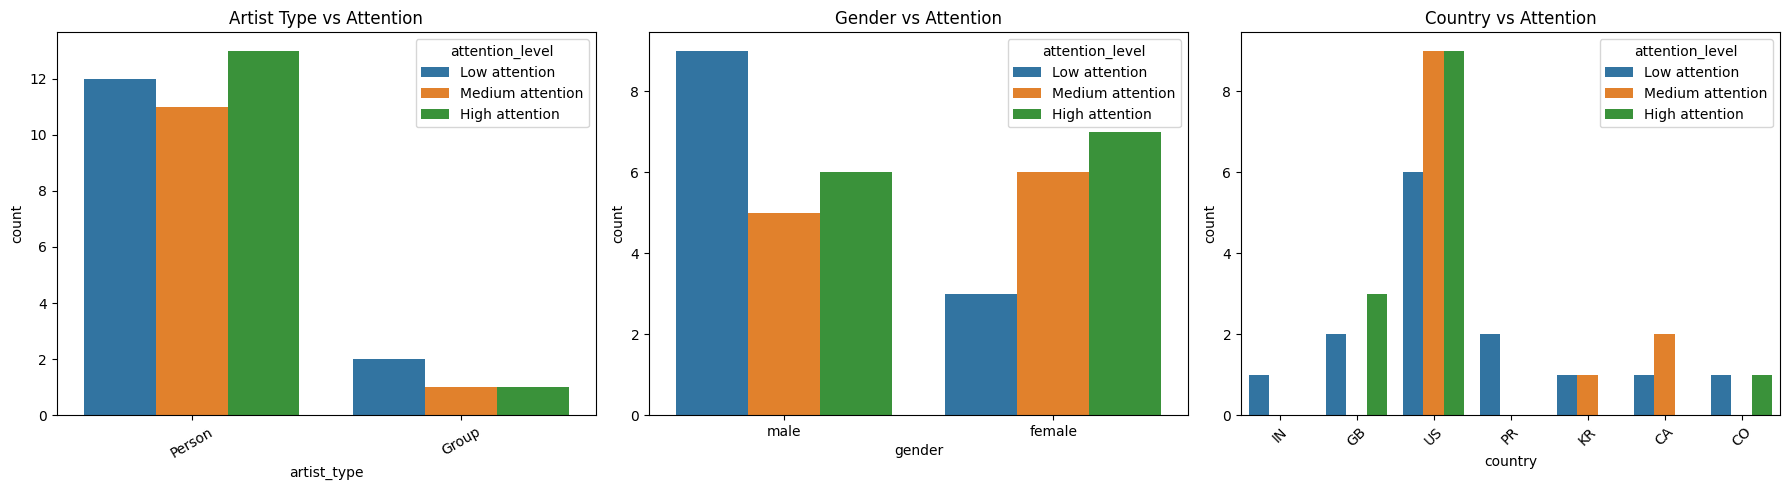

In [19]:
# We will compare attention levels against artist type, gender, country, release count and career history.

# Artist type, gender and country

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=df, x='artist_type',
    hue='attention_level', ax=axes[0]
)
axes[0].set_title('Artist Type vs Attention')
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(
    data=df, x='gender',
    hue='attention_level', ax=axes[1]
)
axes[1].set_title('Gender vs Attention')

sns.countplot(
    data=df, x='country',
    hue='attention_level', ax=axes[2]
)
axes[2].set_title('Country vs Attention')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

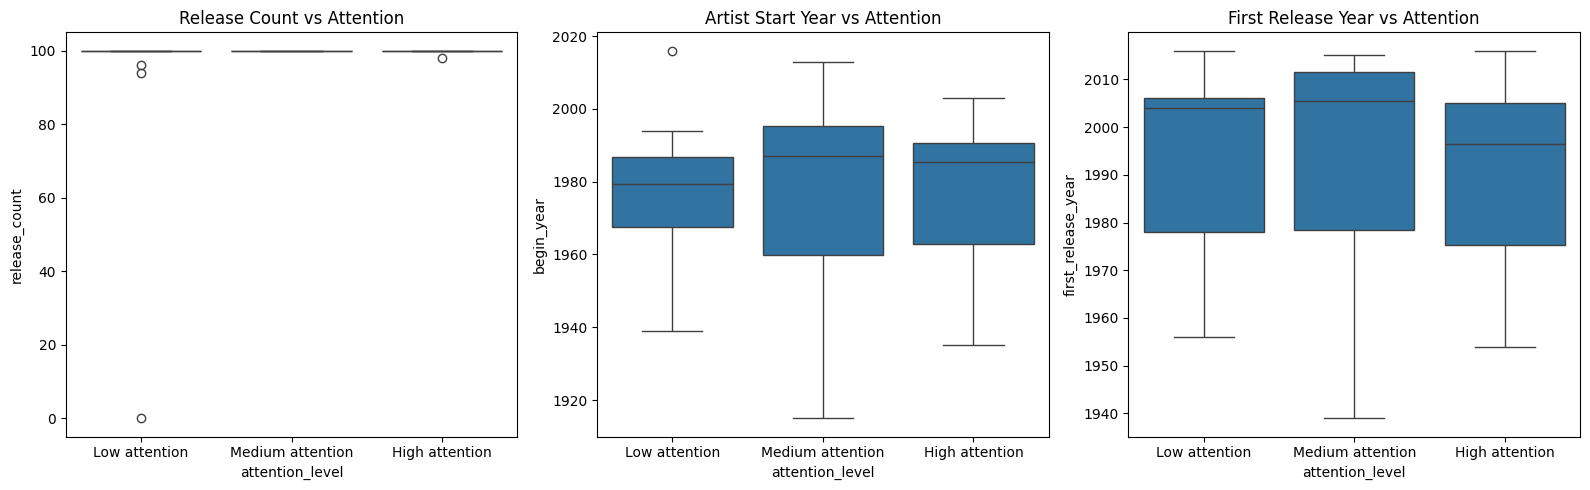

In [20]:
# Numerical characteristics vs attention

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(
    data=df, x='attention_level',
    y='release_count', ax=axes[0]
)
axes[0].set_title('Release Count vs Attention')

sns.boxplot(
    data=df, x='attention_level',
    y='begin_year', ax=axes[1]
)
axes[1].set_title('Artist Start Year vs Attention')

sns.boxplot(
    data=df, x='attention_level',
    y='first_release_year', ax=axes[2]
)
axes[2].set_title('First Release Year vs Attention')

plt.tight_layout()
plt.show()

In [21]:
# Compare median characteristics by attention category

summary = df.groupby(
    'attention_level', observed=False
)[[
    'median_daily_views',
    'release_count',
    'begin_year',
    'first_release_year',
    'last_release_year'
]].median()

print(summary)

                  median_daily_views  release_count  begin_year  \
attention_level                                                   
Low attention                 1422.0          100.0      1979.5   
Medium attention              5784.0          100.0      1987.0   
High attention                9582.0          100.0      1985.5   

                  first_release_year  last_release_year  
attention_level                                          
Low attention                 2004.0             2011.0  
Medium attention              2005.5             2011.5  
High attention                1996.5             2007.5  


The exploratory analysis shows that audience attention varies substantially across artists. Quantile-based categorization provides three reasonably balanced target classes. Gender, country, artist type, release history and music tags are potential explanatory features, but their relationships with attention need further testing.

#Preprocessing

##Handle missing values

In [22]:
# We must keep rows with available target values and handle missing values in the input features separately.

# Remove duplicate records
df = df.drop_duplicates().copy()

# The target cannot be created when median_daily_views is missing
df = df.dropna(subset=['median_daily_views']).copy()

# Create target variable
df['attention_level'] = pd.qcut(
    df['median_daily_views'],
    q=3,
    labels=['Low attention', 'Medium attention', 'High attention']
)

# Columns that should not be used as predictive inputs
remove_columns = [
    'artist_mbid',
    'artist_name',
    'disambiguation',
    'source',
    'median_daily_views',
    'total_pageviews',
    'pageview_days'
]

df = df.drop(columns=remove_columns, errors='ignore')

print("Shape after cleaning:", df.shape)
print(df.isnull().sum())

Shape after cleaning: (40, 9)
artist_type           0
gender                4
country               1
begin_year            0
top_tags              0
release_count         0
first_release_year    1
last_release_year     1
attention_level       0
dtype: int64


We remove median_daily_views from the input because it directly determines the target. total_pageviews and pageview_days are also excluded to avoid using closely related audience statistics as shortcuts for prediction.

##Create meaningful features from year and release information

In [23]:
# Convert year and count columns to numeric when present
year_columns = [
    'begin_year',
    'first_release_year',
    'last_release_year',
    'release_count'
]

for col in year_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Career duration based on first and last release years
if {'first_release_year', 'last_release_year'}.issubset(df.columns):
    df['career_duration'] = (
        df['last_release_year'] - df['first_release_year']
    ).clip(lower=0)

# Release activity per career year
if {'release_count', 'career_duration'}.issubset(df.columns):
    df['releases_per_year'] = (
        df['release_count'] / df['career_duration'].replace(0, np.nan)
    )

# Difference between artist start year and first release
if {'begin_year', 'first_release_year'}.issubset(df.columns):
    df['years_to_first_release'] = (
        df['first_release_year'] - df['begin_year']
    ).clip(lower=0)

print(df[
    [c for c in [
        'career_duration',
        'releases_per_year',
        'years_to_first_release'
    ] if c in df.columns]
].head())

   career_duration  releases_per_year  years_to_first_release
0              7.0          14.285714                    23.0
1              6.0          16.666667                    17.0
2             20.0           5.000000                    14.0
3              3.0          32.666667                    18.0
5              2.0          47.000000                    22.0


- career_duration: estimates how many years separate the first and last releases.
- releases_per_year: estimates release frequency during that period.
- years_to_first_release: estimates the gap between the artist's recorded start year and first release.

These features may capture patterns that are not obvious from the original columns alone. They are approximations: a missing or zero career duration can make release frequency undefined, which is why the preprocessing pipeline will impute missing values.

##Process the top_tags feature

In [25]:
# We will use CountVectorizer to convert individual tags into numerical features.

# Standardize tags before vectorization
if 'top_tags' in df.columns:
    df['top_tags'] = (
        df['top_tags']
        .fillna('')
        .astype(str)
        .str.lower()
        .str.replace('|', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

##Identify and encode categorical variables, and scale numerical variables

In [31]:
# 1. SEPARATE FEATURES AND TARGET

X = df.drop(columns=['attention_level'])
y = df['attention_level'].astype(str)

class_names = [
    'Low attention',
    'Medium attention',
    'High attention'
]

y = pd.Categorical(
    y,
    categories=class_names
).codes.astype('int32')

assert (y >= 0).all(), "Unexpected or missing target labels."

# 2. IDENTIFY FEATURE TYPES

tag_column = 'top_tags' if 'top_tags' in X.columns else None

numerical_features = X.select_dtypes(
    include=['number']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

# Process top_tags separately because it contains multiple tags
if tag_column and tag_column in categorical_features:
    categorical_features.remove(tag_column)

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Tag feature:", tag_column)

# 3. SPLIT DATA BEFORE FITTING PREPROCESSORS

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 4. NUMERICAL FEATURES: IMPUTE AND SCALE

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 5. CATEGORICAL FEATURES: IMPUTE AND ENCODE

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 6. TOP_TAGS: CONVERT INDIVIDUAL TAGS INTO FEATURES

def extract_text_column(data):
    return np.asarray(data).reshape(-1).astype(str)

tag_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value=''
    )),
    ('flatten', FunctionTransformer(
        extract_text_column,
        validate=False
    )),
    ('vectorizer', CountVectorizer(
        token_pattern=r'(?u)\b\w+\b',
        binary=True
    ))
])

# 7. COMBINE PREPROCESSING PIPELINES

transformers = [
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
]

if tag_column:
    transformers.append(
        ('tags', tag_pipeline, [tag_column])
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

# 8. FIT ON TRAINING DATA, TRANSFORM BOTH SETS

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrices to NumPy arrays for TensorFlow
def to_dense(data):
    if hasattr(data, 'toarray'):
        data = data.toarray()
    return np.asarray(data, dtype=np.float32)

X_train_processed = to_dense(X_train_processed)
X_test_processed = to_dense(X_test_processed)

# 9. VERIFY RESULTS

print("\nPreprocessing completed!")
print("Training features:", X_train_processed.shape)
print("Testing features:", X_test_processed.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

print("\nTarget label mapping:")
for i, name in enumerate(class_names):
    print(i, "=", name)

print("\nMissing values in training features:",
      np.isnan(X_train_processed).sum())

print("Missing values in testing features:",
      np.isnan(X_test_processed).sum())

assert X_train_processed.shape[1] == X_test_processed.shape[1]
assert np.isfinite(X_train_processed).all()
assert np.isfinite(X_test_processed).all()

print("\nAll checks passed!")


Numerical features: ['begin_year', 'release_count', 'first_release_year', 'last_release_year', 'career_duration', 'releases_per_year', 'years_to_first_release']
Categorical features: ['artist_type', 'gender', 'country']
Tag feature: top_tags

Preprocessing completed!
Training features: (30, 94)
Testing features: (10, 94)
Training labels: (30,)
Testing labels: (10,)

Target label mapping:
0 = Low attention
1 = Medium attention
2 = High attention

Missing values in training features: 0
Missing values in testing features: 0

All checks passed!


Feature scaling is important because numerical features can have very different ranges. For example, a release count may be in the hundreds, while a year may be around 2,000.
Without scaling, features with larger numerical ranges can dominate the optimization process and make training less stable. StandardScaler transforms numerical features to approximately zero mean and unit variance using statistics learned from the training data.

#Building DNN model

##Prepare training and validation data

In [34]:
# We will split the existing training data again to create validation data. The test set will remain untouched until the final evaluation.

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training samples:", X_fit.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test_processed.shape[0])
print("Input features:", X_fit.shape[1])

Training samples: 24
Validation samples: 6
Testing samples: 10
Input features: 94


##Build the DNN architecture

In [35]:
def build_dnn(
    input_dim,
    neurons=32,
    dropout_rate=0.3,
    learning_rate=0.001
):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(neurons, activation='relu'),
        Dropout(dropout_rate),

        Dense(neurons // 2, activation='relu'),
        Dropout(dropout_rate),

        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

##Tuning hyperparameters

In [36]:
# We will compare four configurations, varying the number of neurons, dropout rate, learning rate, and batch size.
# Each configuration will use early stopping, with a maximum of 100 epochs.

# Four hyperparameter configurations
configs = [
    {
        'name': 'Model A',
        'neurons': 32,
        'dropout': 0.2,
        'learning_rate': 0.001,
        'batch_size': 8
    },
    {
        'name': 'Model B',
        'neurons': 64,
        'dropout': 0.3,
        'learning_rate': 0.001,
        'batch_size': 8
    },
    {
        'name': 'Model C',
        'neurons': 32,
        'dropout': 0.4,
        'learning_rate': 0.0005,
        'batch_size': 4
    },
    {
        'name': 'Model D',
        'neurons': 64,
        'dropout': 0.2,
        'learning_rate': 0.0005,
        'batch_size': 16
    }
]

results = []
histories = {}
models = {}

for config in configs:
    print(f"\nTraining {config['name']}")

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = build_dnn(
        input_dim=X_fit.shape[1],
        neurons=config['neurons'],
        dropout_rate=config['dropout'],
        learning_rate=config['learning_rate']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=config['batch_size'],
        callbacks=[early_stopping],
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        X_val, y_val, verbose=0
    )

    results.append({
        **config,
        'epochs_trained': len(history.history['loss']),
        'best_val_loss': min(history.history['val_loss']),
        'val_accuracy': val_accuracy
    })

    histories[config['name']] = history
    models[config['name']] = model

results_df = pd.DataFrame(results)

print("\nHyperparameter comparison:")
print(
    results_df.sort_values(
        by='best_val_loss'
    ).to_string(index=False)
)


Training Model A

Training Model B

Training Model C

Training Model D

Hyperparameter comparison:
   name  neurons  dropout  learning_rate  batch_size  epochs_trained  best_val_loss  val_accuracy
Model A       32      0.2         0.0010           8              94       0.849366           0.5
Model B       64      0.3         0.0010           8              73       0.901439           0.5
Model D       64      0.2         0.0005          16             100       0.966123           0.5
Model C       32      0.4         0.0005           4             100       0.978367           0.5


##Select the best model

In [37]:
# We will select the configuration with the lowest validation loss, then inspect its learning curves.

best_config_name = results_df.loc[
    results_df['best_val_loss'].idxmin(),
    'name'
]

best_model = models[best_config_name]
best_history = histories[best_config_name]

print("Selected model:", best_config_name)

print(
    results_df.loc[
        results_df['name'] == best_config_name
    ].to_string(index=False)
)

Selected model: Model A
   name  neurons  dropout  learning_rate  batch_size  epochs_trained  best_val_loss  val_accuracy
Model A       32      0.2          0.001           8              94       0.849366           0.5


##Plot training and validation loss

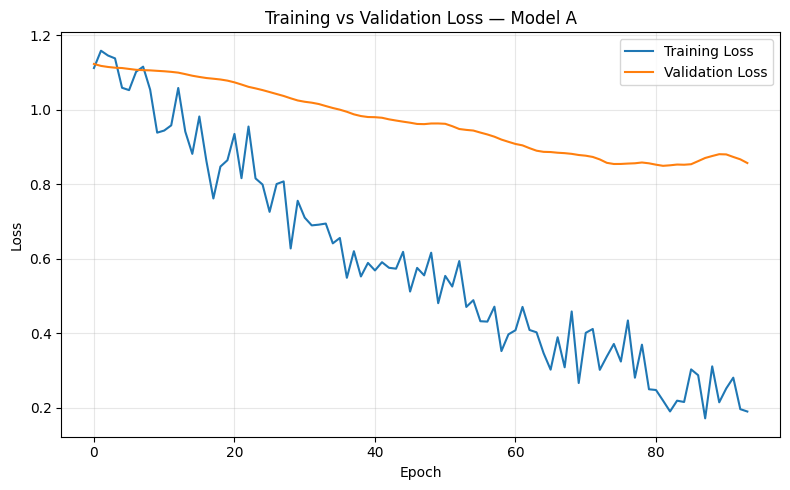

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history['loss'],
    label='Training Loss'
)
plt.plot(
    best_history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training vs Validation Loss — {best_config_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Plot training and validation accuracy

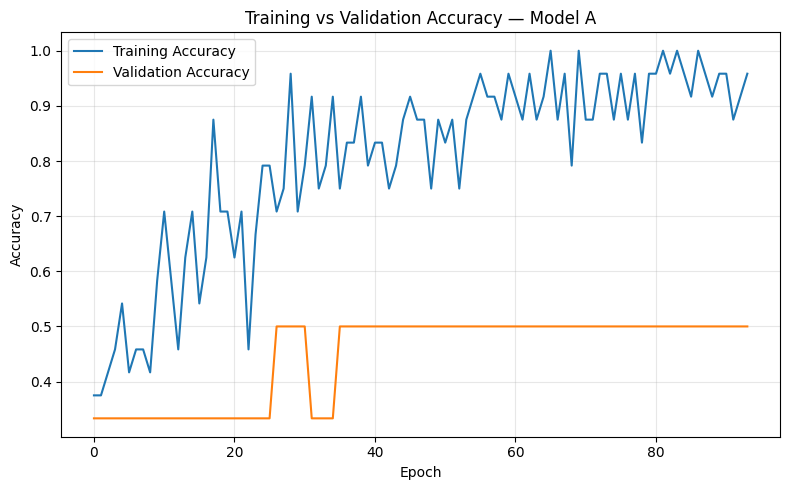

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    best_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'Training vs Validation Accuracy — {best_config_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Evaluate the selected model on test data

Test Loss: 1.1174
Test Accuracy: 0.4000

Classification Report:
                  precision    recall  f1-score   support

   Low attention       0.67      0.50      0.57         4
Medium attention       0.00      0.00      0.00         3
  High attention       0.33      0.67      0.44         3

        accuracy                           0.40        10
       macro avg       0.33      0.39      0.34        10
    weighted avg       0.37      0.40      0.36        10



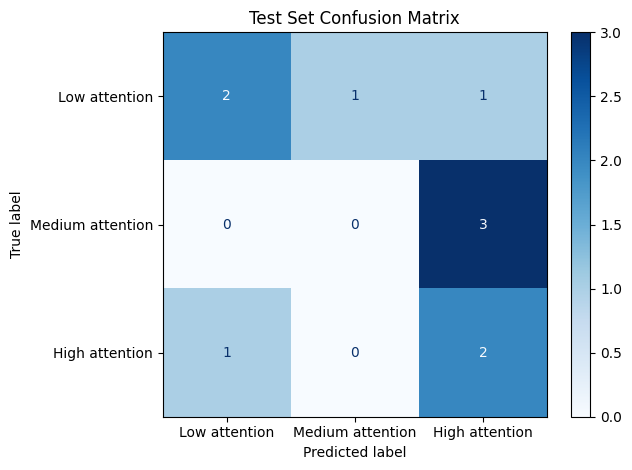

In [40]:
test_loss, test_accuracy = best_model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

y_prob = best_model.predict(
    X_test_processed,
    verbose=0
)

y_pred = np.argmax(y_prob, axis=1)

class_names = [
    'Low attention',
    'Medium attention',
    'High attention'
]

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(cmap='Blues', values_format='d')

plt.title('Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

The Softmax activation function is appropriate because this is a multiclass classification problem with three mutually exclusive classes: Low attention, Medium attention and High attention.

Softmax converts the output scores into probabilities that sum to 1. The class with the highest predicted probability becomes the model's predicted attention category.

#Final DNN Evaluation

##Calculate classification metrics and display the classification report

In [42]:
# Class labels must match the encoding used during training
class_names = [
    'Low attention',
    'Medium attention',
    'High attention'
]

# Predict using the selected final model
y_prob = best_model.predict(X_test_processed, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred,
    labels=[0, 1, 2],
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test, y_pred,
    labels=[0, 1, 2],
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test, y_pred,
    labels=[0, 1, 2],
    average='macro',
    zero_division=0
)

print("========== FINAL DNN EVALUATION ==========")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1-score : {f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=class_names,
    zero_division=0
))

========== FINAL DNN EVALUATION ==========
Accuracy       : 0.4000
Macro Precision: 0.3333
Macro Recall   : 0.3889
Macro F1-score : 0.3386

========== CLASSIFICATION REPORT ==========
                  precision    recall  f1-score   support

   Low attention       0.67      0.50      0.57         4
Medium attention       0.00      0.00      0.00         3
  High attention       0.33      0.67      0.44         3

        accuracy                           0.40        10
       macro avg       0.33      0.39      0.34        10
    weighted avg       0.37      0.40      0.36        10



##Plot the confusion matrix

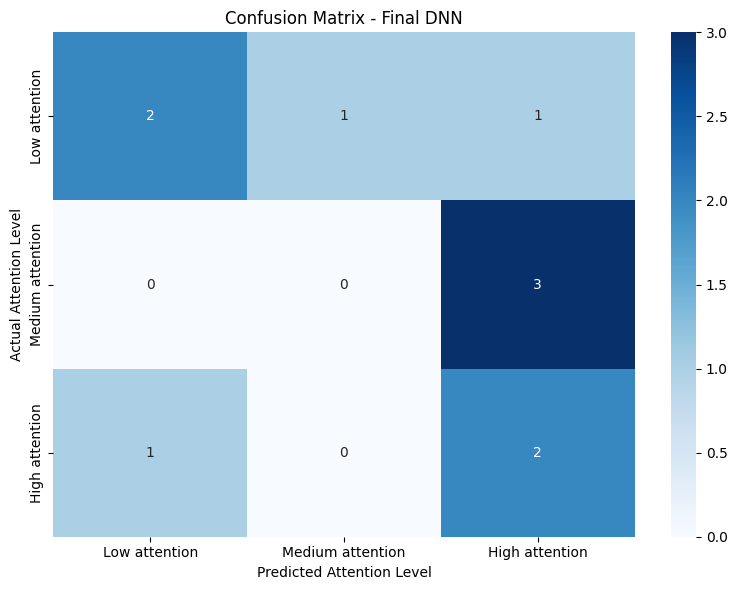

Confusion matrix:
[[2 1 1]
 [0 0 3]
 [1 0 2]]


In [43]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - Final DNN')
plt.xlabel('Predicted Attention Level')
plt.ylabel('Actual Attention Level')
plt.tight_layout()
plt.show()

print("Confusion matrix:")
print(cm)

##3. Identify incorrectly classified artists

In [44]:
# This cell compares the actual attention category with the DNN's prediction and displays the artists the model classified incorrectly.

# Create prediction results
results = pd.DataFrame({
    'actual_label': y_test,
    'predicted_label': y_pred,
    'actual_attention': [
        class_names[i] for i in y_test
    ],
    'predicted_attention': [
        class_names[i] for i in y_pred
    ],
    'correct': y_test == y_pred
})

# Preserve the test records' original indices
results.index = X_test.index

# Retrieve artist names from the original CSV
raw_df = pd.read_csv('/content/artist_attention_summary.csv')

if 'artist_name' in raw_df.columns:
    results['artist_name'] = raw_df.loc[
        results.index, 'artist_name'
    ].values
else:
    results['artist_name'] = results.index.astype(str)

# Identify errors
incorrect = results[~results['correct']].copy()

print("Number of incorrect predictions:", len(incorrect))
print("\nIncorrectly classified artists:")

if incorrect.empty:
    print("No incorrect predictions on this test set.")
else:
    print(incorrect[[
        'artist_name',
        'actual_attention',
        'predicted_attention'
    ]].to_string(index=False))

Number of incorrect predictions: 6

Incorrectly classified artists:
    artist_name actual_attention predicted_attention
      Bob Dylan Medium attention      High attention
         Prince    Low attention      High attention
     Katy Perry Medium attention      High attention
      Bad Bunny    Low attention    Medium attention
Whitney Houston Medium attention      High attention
        Shakira   High attention       Low attention


##Identify the most difficult attention category

In [45]:
# The category with the lowest recall is the category for which the model misses the largest proportion of actual artists.
# We will also count the misclassifications for each actual category

# Count errors for each actual class
error_counts = (
    incorrect['actual_attention']
    .value_counts()
    .reindex(class_names, fill_value=0)
)

# Calculate recall for each class
class_recalls = recall_score(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    average=None,
    zero_division=0
)

category_analysis = pd.DataFrame({
    'Attention category': class_names,
    'Incorrect predictions': error_counts.values,
    'Recall': class_recalls
})

print(category_analysis.to_string(index=False))

# Find the category with lowest recall
lowest_recall_idx = np.argmin(class_recalls)

print(
    "\nCategory with lowest recall:",
    class_names[lowest_recall_idx]
)

if incorrect.empty:
    print("There were no classification errors in this test set.")
else:
    most_errors = error_counts.max()
    hardest_by_count = error_counts[
        error_counts == most_errors
    ].index.tolist()

    print(
        "Category/categories with the most missed artists:",
        hardest_by_count
    )

Attention category  Incorrect predictions   Recall
     Low attention                      2 0.500000
  Medium attention                      3 0.000000
    High attention                      1 0.666667

Category with lowest recall: Medium attention
Category/categories with the most missed artists: ['Medium attention']


##Investigate characteristics of misclassified artists

In [46]:
# To investigate why some predictions may be wrong, compare the characteristics of correctly and incorrectly classified artists.
# Potential explanations include overlapping release histories, similar music tags, missing demographic data, and limited examples in particular categories.

# Join the prediction results with the original test features
diagnostics = X_test.copy()

diagnostics['actual_attention'] = [
    class_names[i] for i in y_test
]
diagnostics['predicted_attention'] = [
    class_names[i] for i in y_pred
]
diagnostics['correct'] = y_test == y_pred

# Attach artist names
diagnostics['artist_name'] = raw_df.loc[
    diagnostics.index, 'artist_name'
].values

# Display the characteristics of incorrectly classified artists
error_details = diagnostics.loc[
    ~diagnostics['correct']
].copy()

display_columns = [
    'artist_name',
    'actual_attention',
    'predicted_attention'
]

# Add available useful characteristics
for col in [
    'artist_type',
    'gender',
    'country',
    'release_count',
    'career_duration',
    'releases_per_year',
    'years_to_first_release',
    'top_tags'
]:
    if col in error_details.columns:
        display_columns.append(col)

print("Misclassified artist details:")
if error_details.empty:
    print("No misclassified artists to investigate.")
else:
    print(error_details[display_columns].to_string(index=False))

# Compare numerical feature medians for correct and incorrect predictions
numeric_cols = diagnostics.select_dtypes(
    include=['number']
).columns.tolist()

numeric_cols = [
    c for c in numeric_cols
    if c not in ['correct']
]

if numeric_cols:
    print("\nMedian numerical characteristics:")
    print(
        diagnostics.groupby('correct')[numeric_cols]
        .median()
        .rename(index={
            True: 'Correct predictions',
            False: 'Incorrect predictions'
        }).T
    )

Misclassified artist details:
    artist_name actual_attention predicted_attention artist_type gender country  release_count  career_duration  releases_per_year  years_to_first_release                                         top_tags
      Bob Dylan Medium attention      High attention      Person   male      US            100             17.0           5.882353                    15.0 folk rock folk rock blues rock singer-songwriter
         Prince    Low attention      High attention      Person   male      US            100              2.0          50.000000                    20.0         funk pop rock contemporary r&b funk rock
     Katy Perry Medium attention      High attention      Person female      US            100              9.0          11.111111                    17.0  pop pop rock electropop dance-pop bubblegum pop
      Bad Bunny    Low attention    Medium attention      Person   male      PR             94              2.0          47.000000                    22.0

Macro F1-score is a useful primary metric for this multiclass classification problem because it balances precision and recall across all three attention categories and gives each category equal weight.



#Saving the model

In [52]:
best_model.save("/content/artist_attention_dnn.keras")

joblib.dump(
    preprocessor,
    "/content/artist_attention_preprocessor.pkl"
)

['/content/artist_attention_preprocessor.pkl']

#Streamlit Deployment

In [69]:
# Creating app.py for streamlit deployment

%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(
    page_title="Artist Attention Predictor",
    page_icon="🎵",
    layout="centered"
)

st.title("🎵 Artist Attention Prediction")
st.write(
    "Predict whether an artist has Low, Medium, "
    "or High audience attention using a trained DNN."
)

st.info("Make sure your trained model and preprocessor are loaded.")

# Check that the model and preprocessor exist in the notebook.
if "best_model" in globals() and "preprocessor" in globals():
    st.success("DNN model and preprocessor are available.")

    artist_type = st.selectbox(
        "Artist type",
        ["Person", "Group", "Other", "Unknown"]
    )

    gender = st.selectbox(
        "Gender",
        ["Male", "Female", "Other", "Unknown"]
    )

    country = st.text_input("Country", "United States")
    begin_year = st.number_input(
        "Career start year", min_value=1800, max_value=2026, value=2000
    )
    release_count = st.number_input(
        "Number of releases", min_value=0, value=20
    )
    first_release_year = st.number_input(
        "First release year", min_value=1800, max_value=2026, value=2002
    )
    last_release_year = st.number_input(
        "Last release year", min_value=1800, max_value=2026, value=2024
    )
    top_tags = st.text_input(
        "Artist tags (space-separated)", "rock pop indie"
    )

    if st.button("Predict attention"):
        career_duration = max(
            int(last_release_year - first_release_year), 0
        )
        releases_per_year = (
            release_count / career_duration
            if career_duration > 0 else np.nan
        )
        years_to_first_release = (
            first_release_year - begin_year
        )

        # These columns must match your model's original input columns.
        input_df = pd.DataFrame([{
            "artist_type": artist_type,
            "gender": gender,
            "country": country,
            "begin_year": begin_year,
            "release_count": release_count,
            "first_release_year": first_release_year,
            "last_release_year": last_release_year,
            "career_duration": career_duration,
            "releases_per_year": releases_per_year,
            "years_to_first_release": years_to_first_release,
            "top_tags": top_tags
        }])

        try:
            transformed = preprocessor.transform(input_df)
            probabilities = best_model.predict(
                transformed, verbose=0
            )[0]

            classes = [
                "Low attention",
                "Medium attention",
                "High attention"
            ]
            predicted = classes[int(np.argmax(probabilities))]

            st.subheader(f"Predicted result: {predicted}")
            st.write("Prediction probabilities:")
            st.bar_chart(pd.DataFrame({
                "Probability": probabilities
            }, index=classes))
        except Exception as e:
            st.error(f"Prediction failed: {e}")
            st.warning(
                "Check that the input columns and categories match "
                "the preprocessing pipeline used during training."
            )
else:
    st.error(
        "The model or preprocessor is not loaded. "
        "Run your model-training notebook cells first."
    )

Overwriting app.py


##Launch Streamlit

In [70]:
# Enter ONLY your actual token when prompted

token = getpass("Paste your actual ngrok token here: ")

ngrok.set_auth_token(token.strip())

public_url = ngrok.connect(8501, "http")
print("Your Streamlit app URL:", public_url)

Paste your actual ngrok token here: ··········
Your Streamlit app URL: NgrokTunnel: "https://aspect-refract-overshot.ngrok-free.dev" -> "http://localhost:8501"


In [71]:
!streamlit run /content/app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [75]:
folder = "/content/artist_attention_streamlit"

print("Files inside the project folder:")
print(os.listdir(folder))

Files inside the project folder:
['requirements.txt', 'artist_attention_preprocessor.pkl', 'app.py', 'README.md', 'artist_attention_dnn.keras']


In [76]:
shutil.copy(
    "/content/artist_attention_streamlit/app.py",
    "/content/app.py"
)

print("app.py copied successfully!")

app.py copied successfully!


In [77]:
!streamlit run /content/app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &



---



---

